# Case 1: 2D Facial Pose (MATB) - Figure Reproduction Notebook

This notebook is for loading precomputed MATB outputs and generating case-study figures only.
For full analysis/statistical workflow details, see the submodule at `projects/MATB/Measuring_Workload_Dynamics_in_OpenMATB` (especially the `Pose` directory).

In [ ]:
# --- 1. Load Precomputed Data (Submodule Outputs) ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Resolve repo root whether notebook runs from projects/MATB or repo root
ROOT = Path.cwd().parents[1] if Path.cwd().name == "MATB" else Path.cwd()
SUBMODULE_POSE = ROOT / "projects" / "MATB" / "Measuring_Workload_Dynamics_in_OpenMATB" / "Pose"

# Figure sources (precomputed outputs from submodule)
linear_file = SUBMODULE_POSE / "data" / "processed_data" / "experimental" / "linear_metrics" / "procrustes_global_linear.csv"
rqa_file = SUBMODULE_POSE / "data" / "rqa" / "experimental_procrustes_global_rqa_crqa.csv"

if not linear_file.exists():
    raise FileNotFoundError(f"Missing linear figure source: {linear_file}")
if not rqa_file.exists():
    raise FileNotFoundError(f"Missing RQA figure source: {rqa_file}")

lin_df = pd.read_csv(linear_file)
rqa_wide = pd.read_csv(rqa_file)

lin_df['condition'] = pd.Categorical(
    lin_df['condition'].astype(str).str.strip().str.upper(),
    categories=['L', 'M', 'H'],
    ordered=True,
)
rqa_wide['condition'] = pd.Categorical(
    rqa_wide['condition'].astype(str).str.strip().str.upper(),
    categories=['L', 'M', 'H'],
    ordered=True,
)

print(f"Loaded Linear shape: {lin_df.shape}")
print(f"Loaded RQA shape: {rqa_wide.shape}")

Loaded Linear shape: (3222, 303)
Loaded RQA shape: (3222, 159)


/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_9983/2012405024.py:33: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=c, edgecolor='black', linewidth=2, label=l)
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_9983/2012405024.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_9983/2012405024.py:43: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'black'}` instead.

  sns.barplot(
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_9983/2012405024.py:43: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  sns.barplot(
/var/folders/fg/dc

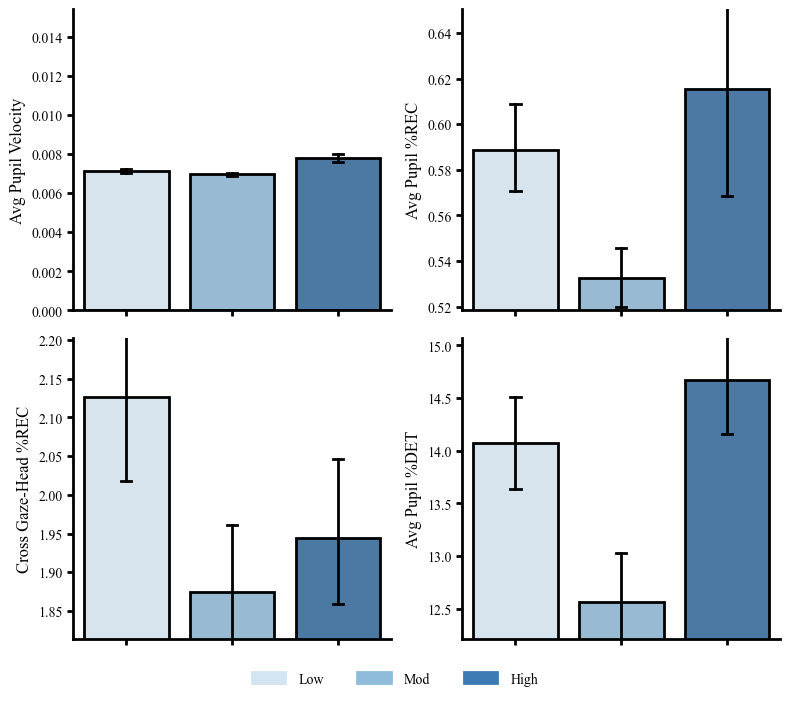

In [8]:
# --- 2. CSV-Driven Plots Across Conditions (Requested Metrics) ---
import matplotlib as mpl
import matplotlib.font_manager as fm

plt.style.use('default')

# Force-load the real Times New Roman font from macOS
tnr_path = Path('/System/Library/Fonts/Supplemental/Times New Roman.ttf')
fm.fontManager.addfont(str(tnr_path))
tnr_fp = fm.FontProperties(fname=str(tnr_path))
tnr_name = tnr_fp.get_name()

# Apply font settings AFTER style so they are not overwritten
mpl.rcParams['font.family'] = [tnr_name]
mpl.rcParams['font.serif'] = [tnr_name, 'Times', 'DejaVu Serif']
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['svg.fonttype'] = 'path'   # outlines for SVG
mpl.rcParams['pdf.fonttype'] = 42        # embed TrueType in PDF

fig, axes = plt.subplots(2, 2, figsize=(8, 7))
axes = axes.flatten()
colors = ['#d3e5f2', '#8fbcdb', '#3c7ab3']

plot_specs = [
    (lin_df, 'pupil_metric_vel_rms', 'Avg Pupil Velocity', axes[0]),
    (rqa_wide, 'pupil_metric_perc_recur', 'Avg Pupil %REC', axes[1]),
    (rqa_wide, 'crqa_head_pupil_mag_perc_recur', 'Cross Gaze-Head %REC', axes[2]),
    (rqa_wide, 'pupil_metric_perc_determ', 'Avg Pupil %DET', axes[3]),
]

import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=c, edgecolor='black', linewidth=2, label=l)
    for c, l in zip(colors, ['Low', 'Mod', 'High'])
]

for df_plot, metric, ylab, ax in plot_specs:
    if metric not in df_plot.columns:
        ax.text(0.5, 0.5, f'Missing:\n{metric}', ha='center', va='center', fontproperties=tnr_fp)
        ax.set_axis_off()
        continue

    sns.barplot(
        data=df_plot,
        x='condition',
        y=metric,
        order=['L', 'M', 'H'],
        ax=ax,
        palette=colors,
        edgecolor='black',
        linewidth=2,
        capsize=0.1,
        errcolor='black',
        errwidth=2,
    )

    stats = (
        df_plot.loc[df_plot['condition'].isin(['L', 'M', 'H']), ['condition', metric]]
        .dropna()
        .groupby('condition', observed=True)[metric]
        .agg(['mean', 'sem'])
        .reindex(['L', 'M', 'H'])
    )
    stats['sem'] = stats['sem'].fillna(0)

    if stats['mean'].notna().any():
        low = (stats['mean'] - stats['sem']).min()
        high = (stats['mean'] + stats['sem']).max()
        span = max(high - low, max(abs(high), 1.0) * 0.15)
        pad = span * 0.05
        ax.set_ylim(max(0, low - pad), high + pad)

    ax.set_ylabel(ylab, fontsize=12, fontproperties=tnr_fp)
    ax.set_xlabel('')
    ax.set_xticklabels(['', '', ''])
    ax.tick_params(axis='x', length=4, width=2)
    ax.tick_params(axis='y', length=4, width=2)

    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontproperties(tnr_fp)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)

legend = fig.legend(
    handles=legend_patches,
    labels=['Low', 'Mod', 'High'],
    loc='lower center',
    ncol=3,
    bbox_to_anchor=(0.5, -0.01),
    fontsize=12,
    frameon=False,
)
for txt in legend.get_texts():
    txt.set_fontproperties(tnr_fp)

out_svg = SUBMODULE_POSE / 'figs' / 'linear_rqa_summary_matb.svg'
out_pdf = SUBMODULE_POSE / 'figs' / 'linear_rqa_summary_matb.pdf'
plt.savefig(out_svg, dpi=300, bbox_inches='tight')
plt.savefig(out_pdf, dpi=300, bbox_inches='tight')
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()